## Importation

In [1]:
import pickle
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    balanced_accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve, accuracy_score,
)

from torch_geometric.data import HeteroData
from torch_geometric.nn import HeteroConv, GATConv, Linear

import optuna

/home/yona/miniconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Graph Preparation 

In [2]:
DATA_ROOT = '/media/Data/Yona/WSI CCRCC'

with open(f'{DATA_ROOT}/embeddings_train.pkl', 'rb') as f:
    train_data = pickle.load(f)
with open(f'{DATA_ROOT}/embeddings_test.pkl', 'rb') as f:
    test_data = pickle.load(f)

X_train = np.array(train_data['embeddings'])
patient_ids_train = np.array(train_data['patient_ids'])

X_test = np.array(test_data['embeddings'])
patient_ids_test = np.array(test_data['patient_ids'])

X_all = np.concatenate([X_train, X_test], axis=0)
patient_ids_all = np.concatenate([patient_ids_train, patient_ids_test], axis=0)

unique_pids = np.unique(patient_ids_all)
num_patients = len(unique_pids)
pid_to_idx = {pid: idx for idx, pid in enumerate(unique_pids)}

# 2) Build heterograph
data = HeteroData()

data['image'].x = torch.tensor(X_all, dtype=torch.float)
data['patient'].x = torch.zeros((num_patients, 1), dtype=torch.float)

source_nodes, target_nodes = [], []
for img_idx, pid in enumerate(patient_ids_all):
    source_nodes.append(img_idx)
    target_nodes.append(pid_to_idx[pid])

data['image', 'to', 'patient'].edge_index = torch.tensor([source_nodes, target_nodes], dtype=torch.long)

print(f"Total number of 'image' nodes : {data['image'].num_nodes}")
print(f"Total number of 'patient' nodes: {data['patient'].num_nodes}")
print(f"Number of edges image→patient  : {data['image', 'to', 'patient'].edge_index.shape[1]}")

# 3) Load and assign clinical/genomic features
df = pd.read_csv(f'{DATA_ROOT}/tables/clinical+genomic_split.csv', index_col='case_id')
df['age_diag'] = df['age_diag'].fillna(df['age_diag'].mean())
df['cancer_history'] = df['cancer_history'].fillna(0)

df_features = df.drop(columns=['vital_status_12', 'Split'])

missing = set(unique_pids) - set(df_features.index)
if missing:
    raise KeyError(f"The following patient IDs are missing from the CSV: {missing}")

df_features = df_features.loc[unique_pids]
data['patient'].x = torch.tensor(df_features.values, dtype=torch.float)

print(f"Shape of data['patient'].x : {data['patient'].x.shape}")

# 4) Load patient labels and split masks
labels = df.loc[unique_pids, 'vital_status_12'].astype(int).values
split  = df.loc[unique_pids, 'Split'].values

data['patient'].y          = torch.tensor(labels, dtype=torch.long)
data['patient'].train_mask = torch.tensor(split == 'train')
data['patient'].val_mask   = torch.tensor(split == 'validation')
data['patient'].test_mask  = torch.tensor(split == 'test')

print(f"Labels shape: {data['patient'].y.shape}")
print(f"Number of train patients: {data['patient'].train_mask.sum().item()}")
print(f"Number of val patients:   {data['patient'].val_mask.sum().item()}")
print(f"Number of test patients:  {data['patient'].test_mask.sum().item()}")


def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def masks_to_index(mask: torch.Tensor) -> torch.Tensor:
    return torch.where(mask)[0]

def compute_class_weights(y_train: torch.Tensor, num_classes: int) -> torch.Tensor:
    counts = torch.bincount(y_train, minlength=num_classes).float()
    counts = torch.clamp(counts, min=1.0)
    return counts.sum() / (num_classes * counts)

@torch.no_grad()
def predict_probs_class1(model, data, idx: torch.Tensor):
    model.eval()
    logits = model(data.x_dict, data.edge_index_dict)
    probs1 = torch.softmax(logits[idx], dim=1)[:, 1]
    y_true = data["patient"].y[idx]
    return probs1.detach().cpu().numpy(), y_true.detach().cpu().numpy()

def best_threshold_for_bacc(probs1: np.ndarray, y_true: np.ndarray, n: int = 19):
    thresholds = np.linspace(0.05, 0.95, n)
    best_thr, best_bacc = 0.5, -1.0
    for thr in thresholds:
        y_pred = (probs1 >= thr).astype(int)
        bacc = balanced_accuracy_score(y_true, y_pred)
        if bacc > best_bacc:
            best_bacc, best_thr = bacc, thr
    return float(best_bacc), float(best_thr)

# Model
class OldStyleOptunaGAT(nn.Module):
    def __init__(
        self,
        in_img: int,
        in_pat: int,
        hidden_dim: int,
        num_classes: int,
        num_layers: int,
        heads: int,
        dropout: float,
        aggr: str = "max",
        edge_dropout: float = 0.0,
    ):
        super().__init__()
        self.dropout = dropout
        self.edge_dropout = edge_dropout

        self.lin_img = Linear(in_img, hidden_dim)
        self.lin_pat = Linear(in_pat, hidden_dim)

        self.convs = nn.ModuleList()
        for _ in range(num_layers):
            self.convs.append(
                HeteroConv(
                    {
                        ("image", "to", "patient"): GATConv(
                            (-1, -1),
                            hidden_dim,
                            heads=heads,
                            concat=False,
                            dropout=dropout,
                            add_self_loops=False,
                        )
                    },
                    aggr=aggr,
                )
            )

        self.lin_hidden = nn.Linear(hidden_dim, hidden_dim)
        self.lin_out = nn.Linear(hidden_dim, num_classes)

    def _apply_edge_dropout(self, edge_index_dict):
        if not (self.training and self.edge_dropout > 0.0):
            return edge_index_dict
        edge_index_dict = dict(edge_index_dict)
        for k, ei in edge_index_dict.items():
            if ei.numel() == 0:
                continue
            m = ei.size(1)
            keep = torch.rand(m, device=ei.device) >= self.edge_dropout
            if keep.sum() < 1:
                keep[torch.randint(0, m, (1,), device=ei.device)] = True
            edge_index_dict[k] = ei[:, keep]
        return edge_index_dict

    def forward(self, x_dict, edge_index_dict):
        edge_index_dict = self._apply_edge_dropout(edge_index_dict)

        x_img = F.relu(self.lin_img(x_dict["image"]))
        x_pat = F.relu(self.lin_pat(x_dict["patient"]))
        x_dict = {"image": x_img, "patient": x_pat}

        for conv in self.convs:
            out = conv(x_dict, edge_index_dict)
            h_pat = out["patient"]
            h_pat = F.relu(h_pat + x_dict["patient"])
            h_pat = F.dropout(h_pat, p=self.dropout, training=self.training)
            x_dict["patient"] = h_pat

        h = F.relu(self.lin_hidden(x_dict["patient"]))
        h = F.dropout(h, p=self.dropout, training=self.training)
        return self.lin_out(h)

# Train loop with ReduceLROnPlateau
def train_with_plateau(
    model: nn.Module,
    data,
    train_idx: torch.Tensor,
    val_idx: torch.Tensor,
    optimizer: torch.optim.Optimizer,
    loss_fn: nn.Module,
    scheduler: torch.optim.lr_scheduler.ReduceLROnPlateau,
    epochs: int,
):
    y = data["patient"].y

    for _ in range(epochs):
        model.train()
        optimizer.zero_grad()

        logits = model(data.x_dict, data.edge_index_dict)
        loss = loss_fn(logits[train_idx], y[train_idx])

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_logits = model(data.x_dict, data.edge_index_dict)
            val_loss = loss_fn(val_logits[val_idx], y[val_idx]).item()

        scheduler.step(val_loss)

# CV Objective: CV only on TRAIN patients
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data = data.to(device)

in_img = data["image"].x.size(1)
in_pat = data["patient"].x.size(1)
num_classes = int(torch.max(data["patient"].y).item() + 1)

FIXED_CLASS_WEIGHTS = torch.tensor([7.5, 1.0], device=device)

# TRAIN patient indices for CV
train_pid_idx = masks_to_index(data["patient"].train_mask.to(device))
y_train_p = data["patient"].y[train_pid_idx].detach().cpu().numpy()

auto_weights = compute_class_weights(data["patient"].y[train_pid_idx], num_classes).to(device)

SEEDS_FOR_OBJECTIVE = [42, 7, 123]
stability_lambda = 0.25

N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

def objective(trial: optuna.Trial) -> float:
    hidden_dim = trial.suggest_categorical("hidden_dim", [32, 64, 96, 128])
    num_layers = trial.suggest_categorical("num_layers", [2, 1, 3])
    heads = trial.suggest_categorical("heads", [1, 2, 4])
    dropout = trial.suggest_float("dropout", 0.10, 0.50)
    aggr = trial.suggest_categorical("aggr", ["max", "mean"])
    edge_dropout = trial.suggest_float("edge_dropout", 0.0, 0.10)

    lr = trial.suggest_float("lr", 1e-4, 1e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-3, 1e-2, log=True)

    epochs = trial.suggest_int("epochs", 40, 120)

    weight_mode = trial.suggest_categorical("weight_mode", ["fixed_7p5_1", "auto"])
    if weight_mode == "fixed_7p5_1":
        loss_fn = nn.CrossEntropyLoss(weight=FIXED_CLASS_WEIGHTS)
    else:
        loss_fn = nn.CrossEntropyLoss(weight=auto_weights)

    seed_scores = []

    for seed in SEEDS_FOR_OBJECTIVE:
        set_seed(seed)

        fold_baccs = []

        for tr_rel, va_rel in skf.split(np.zeros(len(train_pid_idx)), y_train_p):
            tr_idx = train_pid_idx[torch.tensor(tr_rel, device=device)]
            va_idx = train_pid_idx[torch.tensor(va_rel, device=device)]

            model = OldStyleOptunaGAT(
                in_img=in_img,
                in_pat=in_pat,
                hidden_dim=hidden_dim,
                num_classes=num_classes,
                num_layers=num_layers,
                heads=heads,
                dropout=dropout,
                aggr=aggr,
                edge_dropout=edge_dropout,
            ).to(device)

            optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

            scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimizer, mode="min", factor=0.5, patience=5, min_lr=1e-6
            )

            train_with_plateau(
                model=model,
                data=data,
                train_idx=tr_idx,
                val_idx=va_idx,
                optimizer=optimizer,
                loss_fn=loss_fn,
                scheduler=scheduler,
                epochs=epochs,
            )

            probs_va, y_va = predict_probs_class1(model, data, va_idx)
            fold_bacc, _ = best_threshold_for_bacc(probs_va, y_va)
            fold_baccs.append(fold_bacc)

        seed_scores.append(float(np.mean(fold_baccs)))

    mean_score = float(np.mean(seed_scores))
    std_score = float(np.std(seed_scores))

    trial.set_user_attr("cv_bacc_mean", mean_score)
    trial.set_user_attr("cv_bacc_std", std_score)

    return float(mean_score - stability_lambda * std_score)

# Run Optuna
optuna.logging.set_verbosity(optuna.logging.INFO)

sampler = optuna.samplers.TPESampler(seed=42, multivariate=True)
pruner = optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=10)

study = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner)
study.optimize(objective, n_trials=60, show_progress_bar=True)

print("\nBest trial (CV-TRAIN ROBUST):")
print("  Value (robust):", study.best_value)
print("  Params:", study.best_params)
print("  Attrs:", study.best_trial.user_attrs)

best_params = study.best_params

# Final training on ALL TRAIN patients, then evaluate on TEST once
if best_params["weight_mode"] == "fixed_7p5_1":
    final_loss_fn = nn.CrossEntropyLoss(weight=FIXED_CLASS_WEIGHTS)
else:
    final_loss_fn = nn.CrossEntropyLoss(weight=auto_weights)

set_seed(42)

final_model = OldStyleOptunaGAT(
    in_img=in_img,
    in_pat=in_pat,
    hidden_dim=best_params["hidden_dim"],
    num_classes=num_classes,
    num_layers=best_params["num_layers"],
    heads=best_params["heads"],
    dropout=best_params["dropout"],
    aggr=best_params["aggr"],
    edge_dropout=best_params["edge_dropout"],
).to(device)

final_opt = torch.optim.AdamW(
    final_model.parameters(),
    lr=best_params["lr"],
    weight_decay=best_params["weight_decay"],
)

final_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    final_opt, mode="min", factor=0.5, patience=5, min_lr=1e-6
)

val_pid_idx = masks_to_index(data["patient"].val_mask.to(device))
test_pid_idx = masks_to_index(data["patient"].test_mask.to(device))

monitor_idx = val_pid_idx if val_pid_idx.numel() > 0 else train_pid_idx

train_with_plateau(
    model=final_model,
    data=data,
    train_idx=train_pid_idx,
    val_idx=monitor_idx,
    optimizer=final_opt,
    loss_fn=final_loss_fn,
    scheduler=final_scheduler,
    epochs=best_params["epochs"],
)

thr_tune_idx = val_pid_idx if val_pid_idx.numel() > 0 else train_pid_idx
probs_val, y_val = predict_probs_class1(final_model, data, thr_tune_idx)
val_bacc, best_thr = best_threshold_for_bacc(probs_val, y_val)

probs_test, y_test = predict_probs_class1(final_model, data, test_pid_idx)
y_pred_test = (probs_test >= best_thr).astype(int)
test_bacc = float(balanced_accuracy_score(y_test, y_pred_test))

print("\nFinal evaluation (CV-tuned params):")
print("  Tuned thr on VAL (or TRAIN if VAL empty):", best_thr)
print("  VAL BACC:", val_bacc)
print("  TEST BACC:", test_bacc)

Total number of 'image' nodes : 2134
Total number of 'patient' nodes: 617
Number of edges image→patient  : 2134
Shape of data['patient'].x : torch.Size([617, 17])
Labels shape: torch.Size([617])
Number of train patients: 479
Number of val patients:   18
Number of test patients:  120


/home/yona/miniconda3/lib/python3.12/site-packages/optuna/_experimental.py:31: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  warnings.warn(
[I 2026-06-08 17:49:23,134] A new study created in memory with name: no-name-d54f0ba1-aa11-4792-844f-12b1ac0bd817
  0%|          | 0/60 [00:00<?, ?it/s]/home/yona/miniconda3/lib/python3.12/site-packages/torch_geometric/nn/conv/hetero_conv.py:76: UserWarning: There exist node types ({'image'}) whose representations do not get updated during message passing as they do not occur as destination type in any edge type. This may lead to unexpected behavior.
  warnings.warn(
/home/yona/miniconda3/lib/python3.12/site-packages/torch_geometric/nn/conv/hetero_conv.py:76: UserWarning: There exist node types ({'image'}) whose representations do not get updated during message passing as they do not occur as destination type in any edge type. This may lead to unexpected behavior.
  warnings.war

[I 2026-06-08 17:49:39,828] Trial 0 finished with value: 0.6534126073384688 and parameters: {'hidden_dim': 64, 'num_layers': 2, 'heads': 1, 'dropout': 0.10823379771832098, 'aggr': 'max', 'edge_dropout': 0.021233911067827616, 'lr': 0.0001519934830130982, 'weight_decay': 0.0015254729458052604, 'epochs': 64, 'weight_mode': 'fixed_7p5_1'}. Best is trial 0 with value: 0.6534126073384688.


/home/yona/miniconda3/lib/python3.12/site-packages/torch_geometric/nn/conv/hetero_conv.py:76: UserWarning: There exist node types ({'image'}) whose representations do not get updated during message passing as they do not occur as destination type in any edge type. This may lead to unexpected behavior.
  warnings.warn(
/home/yona/miniconda3/lib/python3.12/site-packages/torch_geometric/nn/conv/hetero_conv.py:76: UserWarning: There exist node types ({'image'}) whose representations do not get updated during message passing as they do not occur as destination type in any edge type. This may lead to unexpected behavior.
  warnings.warn(
/home/yona/miniconda3/lib/python3.12/site-packages/torch_geometric/nn/conv/hetero_conv.py:76: UserWarning: There exist node types ({'image'}) whose representations do not get updated during message passing as they do not occur as destination type in any edge type. This may lead to unexpected behavior.
  warnings.warn(
/home/yona/miniconda3/lib/python3.12/sit

[I 2026-06-08 17:50:14,847] Trial 1 finished with value: 0.7421376566465601 and parameters: {'hidden_dim': 64, 'num_layers': 3, 'heads': 4, 'dropout': 0.1185801650879991, 'aggr': 'max', 'edge_dropout': 0.006505159298527952, 'lr': 0.000888966790701893, 'weight_decay': 0.009239150319627255, 'epochs': 105, 'weight_mode': 'fixed_7p5_1'}. Best is trial 1 with value: 0.7421376566465601.


...

[I 2026-06-08 18:08:16,030] Trial 57 finished with value: 0.7450109449094386 and parameters: {'hidden_dim': 96, 'num_layers': 2, 'heads': 4, 'dropout': 0.1482076986792061, 'aggr': 'max', 'edge_dropout': 0.05772158023267419, 'lr': 0.00040465298055752106, 'weight_decay': 0.004631973792062546, 'epochs': 89, 'weight_mode': 'auto'}. Best is trial 21 with value: 0.7557101312777784.


/home/yona/miniconda3/lib/python3.12/site-packages/torch_geometric/nn/conv/hetero_conv.py:76: UserWarning: There exist node types ({'image'}) whose representations do not get updated during message passing as they do not occur as destination type in any edge type. This may lead to unexpected behavior.
  warnings.warn(
/home/yona/miniconda3/lib/python3.12/site-packages/torch_geometric/nn/conv/hetero_conv.py:76: UserWarning: There exist node types ({'image'}) whose representations do not get updated during message passing as they do not occur as destination type in any edge type. This may lead to unexpected behavior.
  warnings.warn(
/home/yona/miniconda3/lib/python3.12/site-packages/torch_geometric/nn/conv/hetero_conv.py:76: UserWarning: There exist node types ({'image'}) whose representations do not get updated during message passing as they do not occur as destination type in any edge type. This may lead to unexpected behavior.
  warnings.warn(
/home/yona/miniconda3/lib/python3.12/sit

[I 2026-06-08 18:08:36,906] Trial 58 finished with value: 0.739244119296546 and parameters: {'hidden_dim': 96, 'num_layers': 1, 'heads': 4, 'dropout': 0.18861580268864964, 'aggr': 'max', 'edge_dropout': 0.06362485774483213, 'lr': 0.0003774574587677334, 'weight_decay': 0.006434673366640981, 'epochs': 118, 'weight_mode': 'auto'}. Best is trial 21 with value: 0.7557101312777784.


/home/yona/miniconda3/lib/python3.12/site-packages/torch_geometric/nn/conv/hetero_conv.py:76: UserWarning: There exist node types ({'image'}) whose representations do not get updated during message passing as they do not occur as destination type in any edge type. This may lead to unexpected behavior.
  warnings.warn(
/home/yona/miniconda3/lib/python3.12/site-packages/torch_geometric/nn/conv/hetero_conv.py:76: UserWarning: There exist node types ({'image'}) whose representations do not get updated during message passing as they do not occur as destination type in any edge type. This may lead to unexpected behavior.
  warnings.warn(
/home/yona/miniconda3/lib/python3.12/site-packages/torch_geometric/nn/conv/hetero_conv.py:76: UserWarning: There exist node types ({'image'}) whose representations do not get updated during message passing as they do not occur as destination type in any edge type. This may lead to unexpected behavior.
  warnings.warn(
/home/yona/miniconda3/lib/python3.12/sit

[I 2026-06-08 18:09:12,164] Trial 59 finished with value: 0.7283524295295927 and parameters: {'hidden_dim': 128, 'num_layers': 3, 'heads': 4, 'dropout': 0.15558355153359196, 'aggr': 'max', 'edge_dropout': 0.0647898943314606, 'lr': 0.0005246721764808971, 'weight_decay': 0.0029777405560818754, 'epochs': 107, 'weight_mode': 'auto'}. Best is trial 21 with value: 0.7557101312777784.

Best trial (CV-TRAIN ROBUST):
  Value (robust): 0.7557101312777784
  Params: {'hidden_dim': 64, 'num_layers': 1, 'heads': 4, 'dropout': 0.14187437990636542, 'aggr': 'max', 'edge_dropout': 0.01565815912796832, 'lr': 0.0006646069686154969, 'weight_decay': 0.009111275301671204, 'epochs': 106, 'weight_mode': 'auto'}
  Attrs: {'cv_bacc_mean': 0.757204742362061, 'cv_bacc_std': 0.005978444337130307}

Final evaluation (CV-tuned params):
  Tuned thr on VAL (or TRAIN if VAL empty): 0.49999999999999994
  VAL BACC: 0.8888888888888888
  TEST BACC: 0.5504807692307692


In [3]:
BEST = {
    "hidden_dim": 64,
    "num_layers": 1,
    "heads": 4,
    "dropout": 0.14187437990636542,
    "aggr": "max",
    "edge_dropout": 0.01565815912796832,
    "lr": 0.0006646069686154969,
    "weight_decay": 0.009111275301671204,
    "epochs": 300,
}

def best_threshold_for_bacc_dense(probs1: np.ndarray, y_true: np.ndarray, n: int = 99):
    thresholds = np.linspace(0.01, 0.99, n)
    best_thr, best_bacc = 0.5, -1.0
    for thr in thresholds:
        y_pred = (probs1 >= thr).astype(int)
        bacc = balanced_accuracy_score(y_true, y_pred)
        if bacc > best_bacc:
            best_bacc, best_thr = bacc, thr
    return float(best_thr), float(best_bacc)

def train_epochs(model, data, train_idx, optimizer, loss_fn, epochs: int):
    y = data["patient"].y
    for _ in range(epochs):
        model.train()
        optimizer.zero_grad()
        logits = model(data.x_dict, data.edge_index_dict)
        loss = loss_fn(logits[train_idx], y[train_idx])
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
        optimizer.step()

def cv_threshold_and_score(
    data,
    BEST: dict,
    class_weight_mode,
    n_splits=5,
    seeds=(42, 7, 123),
):
    device = next(iter(data.x_dict.values())).device

    train_pid_idx = masks_to_index(data["patient"].train_mask).to(device)
    y_train = data["patient"].y[train_pid_idx].detach().cpu().numpy()

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    seed_scores = []
    all_fold_thresholds = []

    for seed in seeds:
        set_seed(seed)
        fold_baccs = []
        fold_thrs = []

        for tr_rel, va_rel in skf.split(np.zeros(len(train_pid_idx)), y_train):
            tr_idx = train_pid_idx[torch.tensor(tr_rel, device=device)]
            va_idx = train_pid_idx[torch.tensor(va_rel, device=device)]

            model = OldStyleOptunaGAT(
                in_img=data["image"].x.size(1),
                in_pat=data["patient"].x.size(1),
                hidden_dim=BEST["hidden_dim"],
                num_classes=int(torch.max(data["patient"].y).item() + 1),
                num_layers=BEST["num_layers"],
                heads=BEST["heads"],
                dropout=BEST["dropout"],
                aggr=BEST["aggr"],
                edge_dropout=BEST["edge_dropout"],
            ).to(device)

            if class_weight_mode is None:
                loss_fn = nn.CrossEntropyLoss()
            else:
                w0, w1 = class_weight_mode
                loss_fn = nn.CrossEntropyLoss(weight=torch.tensor([w0, w1], device=device, dtype=torch.float))

            optimizer = torch.optim.AdamW(
                model.parameters(),
                lr=BEST["lr"],
                weight_decay=BEST["weight_decay"],
            )

            train_epochs(model, data, tr_idx, optimizer, loss_fn, BEST["epochs"])

            probs1_va, y_va = predict_probs_class1(model, data, va_idx)
            thr, fold_best_bacc = best_threshold_for_bacc_dense(probs1_va, y_va)

            fold_thrs.append(thr)
            fold_baccs.append(fold_best_bacc)

        seed_scores.append(float(np.mean(fold_baccs)))
        all_fold_thresholds.extend(fold_thrs)

    mean_cv = float(np.mean(seed_scores))
    std_cv = float(np.std(seed_scores))
    median_thr = float(np.median(np.array(all_fold_thresholds, dtype=float)))

    return mean_cv, std_cv, median_thr, all_fold_thresholds

def train_final_and_test(data, BEST: dict, class_weight_mode, threshold: float, seed: int = 42):
    device = next(iter(data.x_dict.values())).device
    set_seed(seed)

    train_idx = masks_to_index(data["patient"].train_mask).to(device)
    test_idx  = masks_to_index(data["patient"].test_mask).to(device)

    model = OldStyleOptunaGAT(
        in_img=data["image"].x.size(1),
        in_pat=data["patient"].x.size(1),
        hidden_dim=BEST["hidden_dim"],
        num_classes=int(torch.max(data["patient"].y).item() + 1),
        num_layers=BEST["num_layers"],
        heads=BEST["heads"],
        dropout=BEST["dropout"],
        aggr=BEST["aggr"],
        edge_dropout=BEST["edge_dropout"],
    ).to(device)

    if class_weight_mode is None:
        loss_fn = nn.CrossEntropyLoss()
    else:
        w0, w1 = class_weight_mode
        loss_fn = nn.CrossEntropyLoss(weight=torch.tensor([w0, w1], device=device, dtype=torch.float))

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=BEST["lr"],
        weight_decay=BEST["weight_decay"],
    )

    train_epochs(model, data, train_idx, optimizer, loss_fn, BEST["epochs"])

    probs1_test, y_test = predict_probs_class1(model, data, test_idx)
    y_pred = (probs1_test >= threshold).astype(int)

    bacc = float(balanced_accuracy_score(y_test, y_pred))
    acc = float(accuracy_score(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred, digits=4)

    return bacc, acc, cm, report

weight_grid = [None, (3.0, 1.0), (4.0, 1.0)]

results = []

for w in weight_grid:
    mean_cv, std_cv, median_thr, fold_thrs = cv_threshold_and_score(
        data=data,
        BEST=BEST,
        class_weight_mode=w,
        n_splits=5,
        seeds=(42, 7, 123),
    )

    test_bacc, test_acc, cm, report = train_final_and_test(
        data=data,
        BEST=BEST,
        class_weight_mode=w,
        threshold=median_thr,
        seed=42,
    )

    results.append((w, mean_cv, std_cv, median_thr, test_bacc, test_acc))
    print("\n" + "=" * 70)
    print(f"Class weights: {w}")
    print(f"CV BACC mean/std: {mean_cv:.4f} / {std_cv:.4f}")
    print(f"Median threshold from folds: {median_thr:.3f}")
    print(f"TEST Acc:  {test_acc:.4f}")
    print(f"TEST BACC: {test_bacc:.4f}")
    print("Confusion matrix:\n", cm)
    print("Report:\n", report)

print("\nSummary:")
for w, mean_cv, std_cv, thr, tb, ta in results:
    print(f"weights={w} | CV={mean_cv:.4f}±{std_cv:.4f} | thr={thr:.3f} | TEST BACC={tb:.4f} | TEST Acc={ta:.4f}")

/home/yona/miniconda3/lib/python3.12/site-packages/torch_geometric/nn/conv/hetero_conv.py:76: UserWarning: There exist node types ({'image'}) whose representations do not get updated during message passing as they do not occur as destination type in any edge type. This may lead to unexpected behavior.
  warnings.warn(
/home/yona/miniconda3/lib/python3.12/site-packages/torch_geometric/nn/conv/hetero_conv.py:76: UserWarning: There exist node types ({'image'}) whose representations do not get updated during message passing as they do not occur as destination type in any edge type. This may lead to unexpected behavior.
  warnings.warn(
/home/yona/miniconda3/lib/python3.12/site-packages/torch_geometric/nn/conv/hetero_conv.py:76: UserWarning: There exist node types ({'image'}) whose representations do not get updated during message passing as they do not occur as destination type in any edge type. This may lead to unexpected behavior.
  warnings.warn(
/home/yona/miniconda3/lib/python3.12/sit


Class weights: None
CV BACC mean/std: 0.7546 / 0.0044
Median threshold from folds: 0.860
TEST Acc:  0.8333
TEST BACC: 0.6923
Confusion matrix:
 [[ 8  8]
 [12 92]]
Report:
               precision    recall  f1-score   support

           0     0.4000    0.5000    0.4444        16
           1     0.9200    0.8846    0.9020       104

    accuracy                         0.8333       120
   macro avg     0.6600    0.6923    0.6732       120
weighted avg     0.8507    0.8333    0.8410       120



/home/yona/miniconda3/lib/python3.12/site-packages/torch_geometric/nn/conv/hetero_conv.py:76: UserWarning: There exist node types ({'image'}) whose representations do not get updated during message passing as they do not occur as destination type in any edge type. This may lead to unexpected behavior.
  warnings.warn(
/home/yona/miniconda3/lib/python3.12/site-packages/torch_geometric/nn/conv/hetero_conv.py:76: UserWarning: There exist node types ({'image'}) whose representations do not get updated during message passing as they do not occur as destination type in any edge type. This may lead to unexpected behavior.
  warnings.warn(
/home/yona/miniconda3/lib/python3.12/site-packages/torch_geometric/nn/conv/hetero_conv.py:76: UserWarning: There exist node types ({'image'}) whose representations do not get updated during message passing as they do not occur as destination type in any edge type. This may lead to unexpected behavior.
  warnings.warn(
/home/yona/miniconda3/lib/python3.12/sit


Class weights: (3.0, 1.0)
CV BACC mean/std: 0.7660 / 0.0129
Median threshold from folds: 0.780
TEST Acc:  0.7917
TEST BACC: 0.6683
Confusion matrix:
 [[ 8  8]
 [17 87]]
Report:
               precision    recall  f1-score   support

           0     0.3200    0.5000    0.3902        16
           1     0.9158    0.8365    0.8744       104

    accuracy                         0.7917       120
   macro avg     0.6179    0.6683    0.6323       120
weighted avg     0.8364    0.7917    0.8098       120



/home/yona/miniconda3/lib/python3.12/site-packages/torch_geometric/nn/conv/hetero_conv.py:76: UserWarning: There exist node types ({'image'}) whose representations do not get updated during message passing as they do not occur as destination type in any edge type. This may lead to unexpected behavior.
  warnings.warn(
/home/yona/miniconda3/lib/python3.12/site-packages/torch_geometric/nn/conv/hetero_conv.py:76: UserWarning: There exist node types ({'image'}) whose representations do not get updated during message passing as they do not occur as destination type in any edge type. This may lead to unexpected behavior.
  warnings.warn(
/home/yona/miniconda3/lib/python3.12/site-packages/torch_geometric/nn/conv/hetero_conv.py:76: UserWarning: There exist node types ({'image'}) whose representations do not get updated during message passing as they do not occur as destination type in any edge type. This may lead to unexpected behavior.
  warnings.warn(
/home/yona/miniconda3/lib/python3.12/sit


Class weights: (4.0, 1.0)
CV BACC mean/std: 0.7677 / 0.0148
Median threshold from folds: 0.820
TEST Acc:  0.7667
TEST BACC: 0.6803
Confusion matrix:
 [[ 9  7]
 [21 83]]
Report:
               precision    recall  f1-score   support

           0     0.3000    0.5625    0.3913        16
           1     0.9222    0.7981    0.8557       104

    accuracy                         0.7667       120
   macro avg     0.6111    0.6803    0.6235       120
weighted avg     0.8393    0.7667    0.7938       120


Summary:
weights=None | CV=0.7546±0.0044 | thr=0.860 | TEST BACC=0.6923 | TEST Acc=0.8333
weights=(3.0, 1.0) | CV=0.7660±0.0129 | thr=0.780 | TEST BACC=0.6683 | TEST Acc=0.7917
weights=(4.0, 1.0) | CV=0.7677±0.0148 | thr=0.820 | TEST BACC=0.6803 | TEST Acc=0.7667


## Final Model GATConv with the best architecture

Epoch 001 | Train Loss 0.7826 | Train Acc 0.1879 | Val Loss 0.6791 | Val Acc 0.7778
Epoch 010 | Train Loss 0.5264 | Train Acc 0.8935 | Val Loss 0.7241 | Val Acc 0.5000


/home/yona/miniconda3/lib/python3.12/site-packages/torch_geometric/nn/conv/hetero_conv.py:76: UserWarning: There exist node types ({'image'}) whose representations do not get updated during message passing as they do not occur as destination type in any edge type. This may lead to unexpected behavior.
  warnings.warn(


Epoch 020 | Train Loss 0.4013 | Train Acc 0.8956 | Val Loss 0.8937 | Val Acc 0.5000
Epoch 030 | Train Loss 0.3893 | Train Acc 0.8956 | Val Loss 1.1035 | Val Acc 0.5000
Epoch 040 | Train Loss 0.3714 | Train Acc 0.8956 | Val Loss 1.0923 | Val Acc 0.5000
Epoch 050 | Train Loss 0.3504 | Train Acc 0.8956 | Val Loss 1.0378 | Val Acc 0.5000
Epoch 060 | Train Loss 0.3387 | Train Acc 0.8956 | Val Loss 1.0688 | Val Acc 0.5000
Epoch 070 | Train Loss 0.3092 | Train Acc 0.8956 | Val Loss 1.0624 | Val Acc 0.5000
Epoch 080 | Train Loss 0.2836 | Train Acc 0.8956 | Val Loss 0.9586 | Val Acc 0.5000
Epoch 090 | Train Loss 0.2709 | Train Acc 0.8956 | Val Loss 0.8459 | Val Acc 0.5000
Epoch 100 | Train Loss 0.2647 | Train Acc 0.9061 | Val Loss 0.7533 | Val Acc 0.6111
Epoch 110 | Train Loss 0.2531 | Train Acc 0.9061 | Val Loss 0.6704 | Val Acc 0.6667
Epoch 120 | Train Loss 0.2444 | Train Acc 0.9144 | Val Loss 0.6244 | Val Acc 0.7222
Epoch 130 | Train Loss 0.2457 | Train Acc 0.9102 | Val Loss 0.5755 | Val Acc

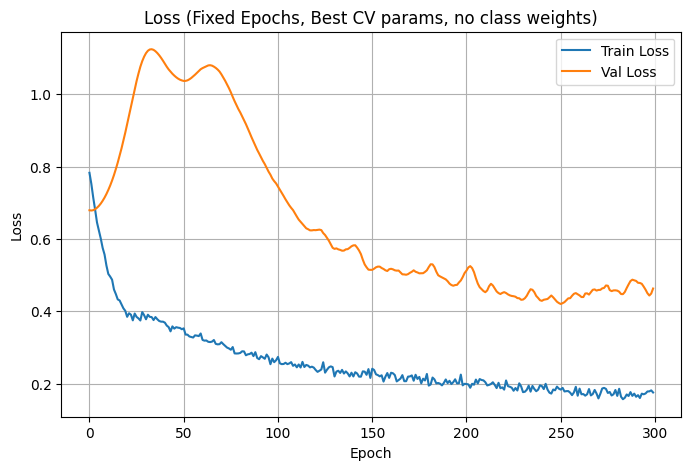

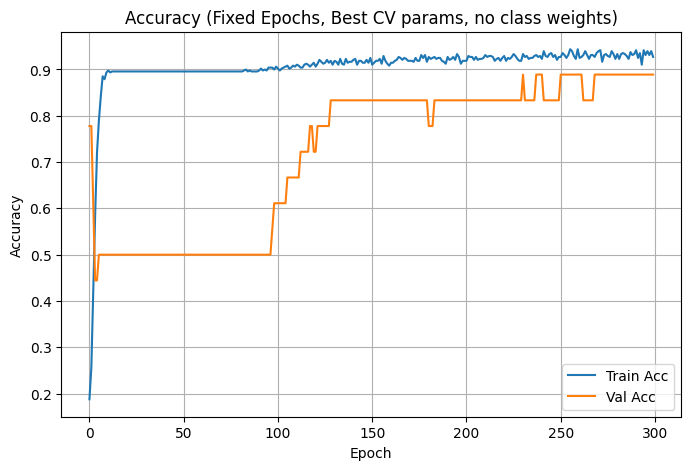

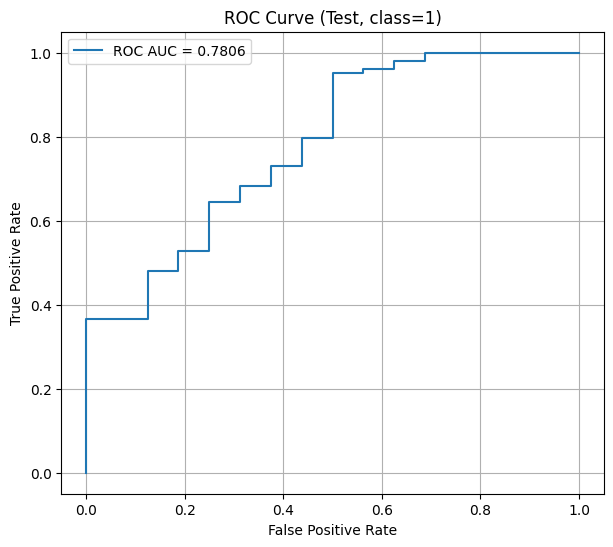

In [4]:
BEST = {
    "hidden_dim": 64,
    "num_layers": 1,
    "heads": 4,
    "dropout": 0.14187437990636542,
    "aggr": "max",
    "edge_dropout": 0.01565815912796832,
    "lr": 0.0006646069686154969,
    "weight_decay": 0.009111275301671204,
    "epochs": 300,
}

FIXED_THR = 0.82

@torch.no_grad()
def get_probs_class(model, data, mask, class_index: int):
    model.eval()
    idx = masks_to_index(mask)
    logits = model(data.x_dict, data.edge_index_dict)
    probs = torch.softmax(logits[idx], dim=1)[:, class_index]
    y_true = data["patient"].y[idx]
    return probs.detach().cpu().numpy(), y_true.detach().cpu().numpy()

@torch.no_grad()
def eval_argmax_metrics(model, data, mask, loss_fn):
    model.eval()
    idx = masks_to_index(mask)
    logits = model(data.x_dict, data.edge_index_dict)
    y_true = data["patient"].y[idx].detach().cpu().numpy()
    y_pred = logits[idx].argmax(dim=1).detach().cpu().numpy()
    loss = float(loss_fn(logits[idx], data["patient"].y[idx]).item())
    acc = float(accuracy_score(y_true, y_pred))
    bacc = float(balanced_accuracy_score(y_true, y_pred))
    return loss, acc, bacc

def train_fixed_epochs_with_history(model, data, train_mask, val_mask, optimizer, loss_fn, epochs):
    train_idx = masks_to_index(train_mask)
    y = data["patient"].y

    train_loss_hist, train_acc_hist = [], []
    val_loss_hist, val_acc_hist = [], []

    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()

        logits = model(data.x_dict, data.edge_index_dict)
        loss = loss_fn(logits[train_idx], y[train_idx])

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
        optimizer.step()

        with torch.no_grad():
            pred_tr = logits[train_idx].argmax(dim=1)
            tr_loss = float(loss.item())
            tr_acc = float(accuracy_score(
                y[train_idx].detach().cpu().numpy(),
                pred_tr.detach().cpu().numpy(),
            ))

        if val_mask is not None and val_mask.any():
            va_loss, va_acc, _ = eval_argmax_metrics(model, data, val_mask, loss_fn)
        else:
            va_loss, va_acc = np.nan, np.nan

        train_loss_hist.append(tr_loss)
        train_acc_hist.append(tr_acc)
        val_loss_hist.append(float(va_loss))
        val_acc_hist.append(float(va_acc))

        if epoch % 10 == 0 or epoch == 1:
            print(
                f"Epoch {epoch:03d} | "
                f"Train Loss {tr_loss:.4f} | Train Acc {tr_acc:.4f} | "
                f"Val Loss {va_loss:.4f} | Val Acc {va_acc:.4f}"
            )

    return train_loss_hist, train_acc_hist, val_loss_hist, val_acc_hist


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data = data.to(device)

set_seed(42)

train_mask = data["patient"].train_mask.to(device)
val_mask   = data["patient"].val_mask.to(device)
test_mask  = data["patient"].test_mask.to(device)

in_img = data["image"].x.size(1)
in_pat = data["patient"].x.size(1)
num_classes = int(torch.max(data["patient"].y).item() + 1)

loss_fn = nn.CrossEntropyLoss()

model = OldStyleOptunaGAT(
    in_img=in_img,
    in_pat=in_pat,
    hidden_dim=BEST["hidden_dim"],
    num_classes=num_classes,
    num_layers=BEST["num_layers"],
    heads=BEST["heads"],
    dropout=BEST["dropout"],
    aggr=BEST["aggr"],
    edge_dropout=BEST["edge_dropout"],
).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=BEST["lr"],
    weight_decay=BEST["weight_decay"],
)

train_loss_hist, train_acc_hist, val_loss_hist, val_acc_hist = train_fixed_epochs_with_history(
    model=model,
    data=data,
    train_mask=train_mask,
    val_mask=val_mask,
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs=BEST["epochs"],
)

# Evaluation on TEST with FIXED threshold from CV folds
probs1_test, y_test = get_probs_class(model, data, test_mask, class_index=1)
y_pred_test = (probs1_test >= FIXED_THR).astype(int)

test_bacc = float(balanced_accuracy_score(y_test, y_pred_test))
test_acc  = float(accuracy_score(y_test, y_pred_test))

print(f"\nFinal TEST metrics (fixed thr={FIXED_THR:.3f}, no class weights):")
print(f"  Test Acc  : {test_acc:.4f}")
print(f"  Test BACC : {test_bacc:.4f}")

cm = confusion_matrix(y_test, y_pred_test)
print(f"\nConfusion Matrix (fixed thr={FIXED_THR:.3f}):")
print(cm)

print(f"\nClassification Report (fixed thr={FIXED_THR:.3f}):")
print(classification_report(y_test, y_pred_test, target_names=["Non-survival (0)", "Survival (1)"], digits=4))

tn, fp, fn, tp = cm.ravel()
recall0 = tn / (tn + fp) if (tn + fp) > 0 else 0.0
recall1 = tp / (tp + fn) if (tp + fn) > 0 else 0.0
print("\nPer-class recall from confusion matrix:")
print(f"  Recall Non-survival (0): {recall0:.4f}")
print(f"  Recall Survival     (1): {recall1:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(train_loss_hist, label="Train Loss")
plt.plot(val_loss_hist, label="Val Loss")
plt.title("Loss (Fixed Epochs, Best CV params, no class weights)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(train_acc_hist, label="Train Acc")
plt.plot(val_acc_hist, label="Val Acc")
plt.title("Accuracy (Fixed Epochs, Best CV params, no class weights)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

auc_test = roc_auc_score(y_test, probs1_test)
fpr, tpr, _ = roc_curve(y_test, probs1_test)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"ROC AUC = {auc_test:.4f}")
plt.title("ROC Curve (Test, class=1)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()